# LADYBUG GRAPH EXPLORATION

Read the embedded graph in **`data/ladybug/rfb.lbug`**. The model is `(Partner)-[:PARTNER_OF {start_date}]->(Company)`. We inspect the database, retrieve neighborhoods and load **three complete, small components** into memory.

Components are **weakly connected**: edge direction is ignored. Partners are identified by name, so namesakes are already merged in this model. Basic CNPJs remain strings to preserve leading zeros.

In [1]:
import os

from pathlib         import Path
from collections     import deque
from contextlib      import closing
from IPython.display import Markdown, display

import pandas            as pd
import networkx          as nx
import ladybug           as lb
import matplotlib.pyplot as plt

In [2]:
ROOT    = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "scripts/constants.py").is_file()
)
DB_PATH = ROOT / "data/ladybug/rfb.lbug"

N_COMPONENTS  = 3
MAX_NODES     = 40
N_CANDIDATES  = 100
MIN_COMPANIES = 2

PRIMARY_KEYS = {
    "Company" : "cnpj"        ,
    "Partner" : "name_partner",
}


dll = (
    os.add_dll_directory(
        str(ROOT / ".ladybug-runtime")
    )
    if   os.name == "nt" and (ROOT / ".ladybug-runtime").is_dir()
    else None
)

if not DB_PATH.is_file():
    raise FileNotFoundError(
        f"Create {DB_PATH} with: python -m scripts.6_load_ladybug"
    )


db   = lb.Database  (
    DB_PATH,
    read_only       =True         ,
    buffer_pool_size=512 * 1024**2,
    max_num_threads =2            ,
)
conn = lb.Connection(db)

def query(cypher, parameters=None):
    with closing(
        conn.execute(
            cypher, parameters or {}
        )
    ) as result:
        return result.get_as_df()

## SCHEMA AND SIZE

These queries return only metadata and counts; full tables remain in the database. The configured 512 MiB limits Ladybug's buffer pool, not total process memory.

In [3]:
query(
    "CALL show_tables() RETURN name, type"
)

,name,type
0,Company,NODE
1,Partner,NODE
2,PARTNER_OF,REL


In [4]:
table = "Company"


display(
    Markdown(f"**{table}**"                        ),
    query   (f"CALL table_info('{table}') RETURN *"),
)

**Company**

,property id,name,type,default expression,primary key
0,0,cnpj,STRING,NULL,True
1,1,corporate_name,STRING,NULL,False
2,2,capital,INT64,NULL,False


In [5]:
table = "Partner"


display(
    Markdown(f"**{table}**"                        ),
    query   (f"CALL table_info('{table}') RETURN *"),
)

**Partner**

,property id,name,type,default expression,primary key
0,0,name_partner,STRING,NULL,True


In [6]:
table = "PARTNER_OF"


display(
    Markdown(f"**{table}**"                        ),
    query   (f"CALL table_info('{table}') RETURN *"),
)

**PARTNER_OF**

,property id,name,type,default expression,storage_direction
0,1,start_date,DATE,NULL,both


In [7]:
counts = {
    "companies"     : "MATCH (c:Company) RETURN count(*) AS total",
    "partners"      : "MATCH (p:Partner) RETURN count(*) AS total",
    "relationships" : "MATCH ( :Partner)-[r:PARTNER_OF]->(:Company) RETURN count(*) AS total",
}


display(
    pd.DataFrame(
        {
            name : [query(statement).iloc[0, 0]]
            for name, statement in counts.items()
        }
    )
)

,companies,partners,relationships
0,15155173,15108589,26059300


## RETRIEVE A NEIGHBORHOOD

Match a node and its immediate neighbors, preserving node and relationship properties. Each query returns at most `MAX_NODES + 1` rows so oversized results can be detected. This neighborhood **may be truncated** and is not necessarily a complete component.

> References: [Ladybug MATCH](https://docs.ladybugdb.com/cypher/query-clauses/match/) and [weakly connected components](https://docs.ladybugdb.com/extensions/algo/wcc/). Expansion here uses Cypher and Python; it does not require the `algo` extension.

In [8]:
def neighborhood(node_type, key, limit=MAX_NODES):
    if not isinstance(limit, int) or limit < 1:
        raise ValueError("limit must be a positive integer.")

    property_name = PRIMARY_KEYS[node_type]

    with closing(
        conn.execute(
            f"""
            MATCH (n:{node_type} {{{property_name}: $key}})
            OPTIONAL MATCH (n)-[r:PARTNER_OF]-(neighbor)
            RETURN n, r, neighbor LIMIT {limit + 1}
            """
            ,
            {"key": key}
        )
    ) as result:
        return nx.Graph(result.get_as_networkx(directed=False))

candidates = query(
    f"""
    MATCH (c:Company)<-[:PARTNER_OF]-(:Partner)
    RETURN c.cnpj AS cnpj LIMIT {int(N_CANDIDATES)}
    """
).cnpj.drop_duplicates().tolist()

if candidates:
    example = neighborhood("Company", candidates[0])

    display(
        pd.DataFrame(
            [
                {
                    key : value
                    for key, value in data.items()
                    if  key in (
                        "_LABEL"        ,
                        "cnpj"          ,
                        "corporate_name",
                        "capital"       ,
                        "name_partner"  ,
                    )
                }
                for _, data in example.nodes(data=True)
            ]
        )
    )

    print(f"Neighborhood: {len(example)} nodes and {example.number_of_edges()} relationships.")
else:
    print("The database contains no relationships to select seeds.")

,_LABEL,cnpj,corporate_name,capital,name_partner
0,Company,01263400,ASSOCIACAO COMERCIAL DO MERCADO SAO SEBASTIAO,0.0,NaN
1,Partner,None,None,NaN,JOAQUIM LOPES DA CUNHA FAVA
2,Partner,None,None,NaN,CUSTODIO QUARESMA DE SA


Neighborhood: 3 nodes and 2 relationships.


## EXPAND UNTIL THE COMPONENT IS COMPLETE

Breadth-first search queries each reached node once, in both directions, until the queue is empty. It retrieves all nodes and relationships in the component, including long paths and cycles, without a depth cutoff.

If the node limit is exceeded, the function returns `None`: **the entire candidate is discarded**. An unknown CNPJ produces an empty graph; an isolated company produces a one-node graph. Company and partner identities remain separate.

Selection uses the first relationships returned by the database, with no guaranteed order, and favors components with at least two companies. This is an exploratory selection, not a representative sample or a global component distribution. Adjust the configuration or replace `candidates` with basic CNPJs of interest.

In [9]:
def connected_component(cnpj, limit=MAX_NODES):
    graph   = nx.Graph()
    visited =      set()

    queue = deque([("Company", cnpj)])

    while queue:
        node_type, key = queue.popleft()

        if (node_type, key) in visited:
            continue

        visited.add   ((node_type, key))
        neighbors = neighborhood(node_type, key, limit)
        graph  .update(neighbors       )

        if len(graph) > limit:
            return None

        for _, data in neighbors.nodes(data=True):
            neighbor_type = data["_LABEL"]

            identity = (
                neighbor_type, data[PRIMARY_KEYS[neighbor_type]]
            )

            if identity not in visited:
                queue.append(identity)

    return graph

In [10]:
components = []
seen       = set()
discarded  = 0

for cnpj in candidates:
    if cnpj in seen:
        continue

    graph = connected_component(cnpj)

    if graph is None:
        discarded += 1
        continue

    companies = {
        data["cnpj"]
        for _, data in graph.nodes(data=True)
        if  data["_LABEL"] == "Company"
    }

    seen.update(companies)

    if len(companies ) >= MIN_COMPANIES:
        components.append(graph)
    if len(components) == N_COMPONENTS :
        break

print(f"{len(components)} complete components; {discarded} searches discarded due to size.")

if len(components) < N_COMPONENTS:
    print("For more examples, increase N_CANDIDATES/MAX_NODES or reduce MIN_COMPANIES.")

display(
    pd.DataFrame(
        [
            {
                "component" : i,
                "companies" : sum(data["_LABEL"] == "Company" for _, data in graph.nodes(data=True)),
                "partners"  : sum(data["_LABEL"] == "Partner" for _, data in graph.nodes(data=True)),

                "nodes"         : len(graph)             ,
                "relationships" : graph.number_of_edges(),
            }
            for i, graph in enumerate(components, 1)
        ]
    )
)

3 complete components; 16 searches discarded due to size.


,component,companies,partners,nodes,relationships
0,1,21,18,39,40
1,2,2,2,4,4
2,3,7,8,15,14


## CLOSE THE DATABASE

The subgraphs are now in memory. The remaining cells display and analyze their data without a database connection. To retrieve new components, rerun from the configuration cell.

In [11]:
conn.close()
db  .close()

if dll is not None:
    dll.close()

## COMPONENT TABLES AND PLOTS

Each component has a dedicated table cell and a separate plot cell. Companies are blue squares and partners are orange circles. Short node IDs (`C1…`, `P1…`) match the tables, which contain the full company and partner names.

Relationship tables show the stored entry date. For repeated source pairs, the loader keeps the earliest non-null date.

The three display pairs below show the first three selected components. To display more, copy a pair and change its zero-based index.

In [12]:
component_views = []

for graph in components:
    companies = sorted(node for node, data in graph.nodes(data=True) if data["_LABEL"] == "Company")
    partners  = sorted(set(graph) - set(companies))

    labels = {
        node : f"{prefix}{i}"
        for prefix, nodes in (("C", companies), ("P", partners))
        for i     , node  in enumerate(nodes, 1)
    }

    component_views.append((graph, companies, partners, labels))

def show_component_tables(index):
    if index >= len(component_views):
        print(f"Component {index + 1} was not selected.")
        return

    graph, companies, partners, labels = component_views[index]

    for title, nodes, fields in (
        ("Companies", companies, ["cnpj", "corporate_name", "capital"]),
        ("Partners" , partners , ["name_partner"                     ]),
    ):
        display(
            Markdown    (f"**{title}**"),
            pd.DataFrame(
                [
                    {
                        "label" : labels[node],
                        **{
                            field : graph.nodes[node][field]
                            for field in fields
                        }
                    }
                    for node in nodes
                ],
                columns=["label", *fields]
            )
        )

    relationships = []
    for source, target, data in graph.edges(data=True):
        company, partner = (source, target) if source in companies else (target, source)

        relationships.append(
            {
                "company"    : labels[company     ],
                "partner"    : labels[partner     ],
                "start_date" : data  ["start_date"],
            }
        )

    display(
        Markdown    ("**Relationships**"),
        pd.DataFrame(
            relationships,
            columns=[
                "company"   ,
                "partner"   ,
                "start_date",
            ]
        )
    )

In [13]:
def plot_component(index):
    if index >= len(component_views):
        print(f"Component {index + 1} was not selected.")
        return

    graph, companies, partners, labels = component_views[index]

    height = max(4, 0.45 * max(len(companies), len(partners)))

    fig, ax = plt.subplots(figsize=(8, height), layout="constrained")

    positions = {
        node : (
            column, 0.5 if len(nodes) == 1 else 1 - i / (len(nodes) - 1)
        )
        for column, nodes in enumerate((companies, partners))
        for i     , node  in enumerate(nodes)
    }

    nx.draw_networkx_edges(graph, positions, ax=ax, alpha=0.35)

    for nodes, color, shape in (
        (companies, "#2563eb", "s"),
        (partners , "#c2410c", "o"),
    ):
        nx.draw_networkx_nodes(
            graph    ,
            positions,
            nodelist  =nodes,
            node_color=color,
            node_shape=shape,
            node_size =350  ,

            ax=ax,
        )

    nx.draw_networkx_labels(
        graph    ,
        positions,
        labels    =labels ,
        font_color="white",
        font_size =8 ,
        ax        =ax,
    )

    ax.set_title(f"Component {index + 1}: {len(graph)} nodes, {graph.number_of_edges()} relationships")
    ax.margins  (x=0.2, y=0.08)
    ax.axis     ("off"        )

    plt.show ()
    plt.close(fig)

### COMPONENT 1

In [14]:
show_component_tables(0)

**Companies**

,label,cnpj,corporate_name,capital
0,C1,02217738,LABORATORIO CITOCENTER LTDA,0
1,C2,08549659,SERPRAM BRASIL SERVICO DE EMERGENCIA E PROTECA...,10000
2,C3,08927033,V. L .AGUILA BARBERAN POUSADA LTDA,60000
3,C4,09317764,MACTTUB PRODUCOES ARTISTICAS LTDA.,1000
4,C5,09594913,TOKI PRODUCOES ARTISTICAS LTDA,1000
5,C6,13593390,PRODIQ QUIMICA LTDA,100000
6,C7,21073190,VICCARI REPRESENTACAO COMERCIAL DE PRODUTOS Q...,1000
7,C8,23265461,ARCA QUIMICA LTDA,100000
8,C9,26474418,TRADECHEMICAL SERVICOS ADMINISTRATIVOS LTDA,20000
9,C10,28739518,BISCUIT DISTRIBUIDORA DE PRODUTOS ALIMENTICIOS...,10000


**Partners**

,label,name_partner
0,P1,ADEMILSON PINHEIRO SILVA
1,P2,ADRIANA DE OLIVEIRA E SILVA
2,P3,CLAUDIA DE OLIVEIRA E SILVA MICHELOTO
3,P4,CLAUDIA RAPELO SILVA
4,P5,DAVI DAMIAO
5,P6,ELIANE MARIA DE AMORIM CAETANO TIBURCIO
6,P7,GILMAR BARTOLO
7,P8,KATIA CARNEIRO DE PAULA
8,P9,LETICIA RIBEIRO BARBOSA
9,P10,MARCOS AFONSO VICCARI


**Relationships**

,company,partner,start_date
0,C2,P1,2006-10-10
1,C2,P11,2008-07-04
2,C8,P1,2015-09-11
3,C12,P1,1991-02-28
4,C6,P1,2011-03-02
5,C14,P1,2024-05-08
6,C13,P11,2021-11-23
7,C8,P18,2015-09-11
8,C12,P13,1992-04-28
9,C6,P15,2011-03-02


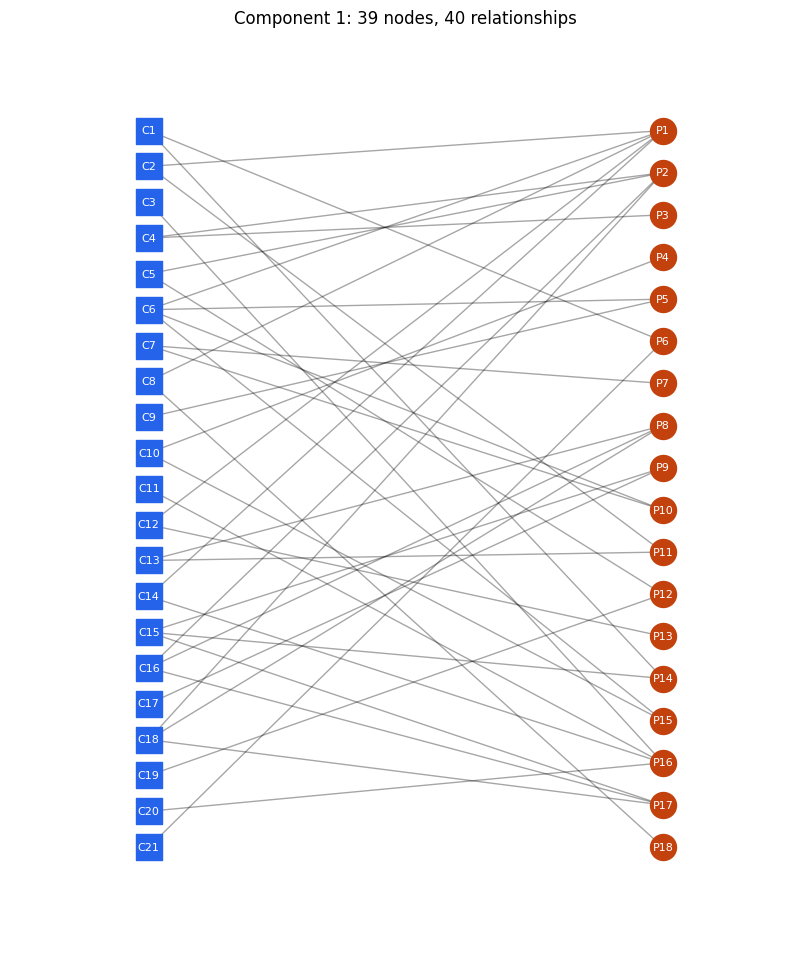

In [15]:
plot_component(0)

### COMPONENT 2

In [16]:
show_component_tables(1)

**Companies**

,label,cnpj,corporate_name,capital
0,C1,00349146,MULT BAURU COMERCIAL DE UTILIDADES DOMESTICAS ...,0
1,C2,65586687,G L GONCALVES SOUZA & FILHO LTDA,100000


**Partners**

,label,name_partner
0,P1,GERCIDES LAUTON GONCALVES SOUZA
1,P2,JOAO GONCALVES DE SOUZA FILHO


**Relationships**

,company,partner,start_date
0,C1,P2,1994-12-12
1,C1,P1,1994-12-12
2,C2,P2,1991-03-04
3,C2,P1,1991-03-04


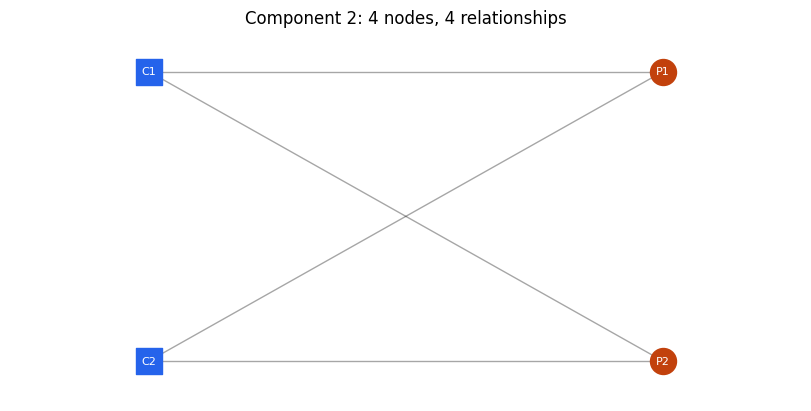

In [17]:
plot_component(1)

### COMPONENT 3

In [18]:
show_component_tables(2)

**Companies**

,label,cnpj,corporate_name,capital
0,C1,04427385,GURITAMA - PLANEJAMENTO LOGISTICA SERVICOS E C...,50000
1,C2,10522907,COBRASMA RECUPERADORA DE CREDITOS LTDA,20000
2,C3,54167150,MPJ EQUIPAMENTOS MEDICOS LTDA,20000
3,C4,62464987,LIMP BEM EMPRESA DE CONSERVACAO LIMPEZA SC LTDA,0
4,C5,62466479,ANCORA EMPRESA DE SERVICOS E COMERCIO LTDA,0
5,C6,62475371,SEVIPA SEGURANCA E VIGILANCIA PATRIMONIAL S/C ...,0
6,C7,96508106,A.D.F.REPRESENTACOES COMERCIAIS E PROMOCIONAIS...,0


**Partners**

,label,name_partner
0,P1,APARECIDO DONIZETI DE FEIRIA
1,P2,APARECIDO DONIZETTI DE FEIRIA
2,P3,FERNANDO AIMOLA
3,P4,GRACIA APARECIDA AIMOLA
4,P5,LAUDEVINO APARECIDO DE OLIVEIRA
5,P6,MARCIA APARECIDA PALMA
6,P7,MARIA APARECIDA DILENARDO
7,P8,SILVIA MARIA PALMA


**Relationships**

,company,partner,start_date
0,C4,P7,1991-03-27
1,C4,P1,1991-03-27
2,C6,P1,1996-06-27
3,C7,P1,1994-05-27
4,C6,P6,1996-06-27
5,C7,P4,1994-05-27
6,C3,P6,2024-05-20
7,C2,P4,2008-11-27
8,C3,P8,2024-05-20
9,C2,P2,2008-11-27


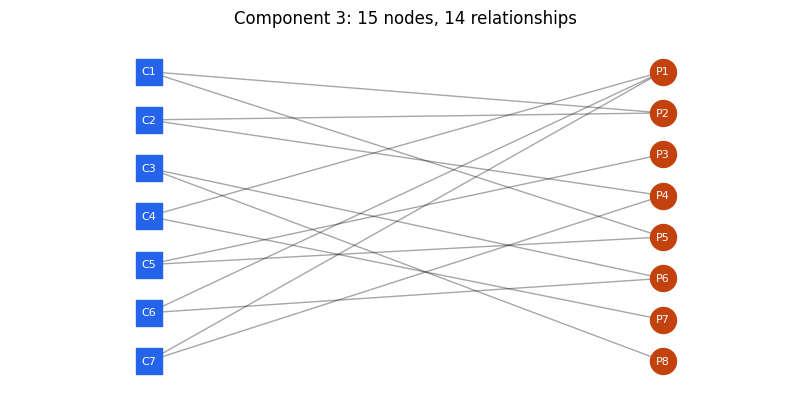

In [19]:
plot_component(2)

## EXPLORE THE SUBGRAPHS IN MEMORY

Check connectivity and count the companies linked to each partner. Completing the expansion queue guarantees completeness relative to the database; `nx.is_connected` checks only connectivity within the loaded graph.

In [20]:
for i, graph in enumerate(components, 1):
    assert nx.is_connected(graph) and nx.is_bipartite(graph)

    display(
        Markdown    (
            f"**Partners by company count — component {i}**"
        ),
        pd.DataFrame(
            [
                {
                    "name_partner" : data["name_partner"],
                    "companies"    : graph.degree(node  ),
                }
                for node, data in graph.nodes(data=True)
                if  data["_LABEL"] == "Partner"
            ],
            columns=["name_partner", "companies"]
        ).sort_values("companies", ascending=False)
    )

**Partners by company count — component 1**

,name_partner,companies
0,ADEMILSON PINHEIRO SILVA,5
7,SUZY PEREIRA DA CUNHA,4
11,ADRIANA DE OLIVEIRA E SILVA,4
12,THAIS NOGUEIRA BARRADAS,3
8,KATIA CARNEIRO DE PAULA,3
1,MARCUS VINICIUS CAVALCANTE COELHO,2
6,MARCOS AFONSO VICCARI,2
13,MARIA DO CARMO DE OLIVEIRA E SILVA,2
5,DAVI DAMIAO,2
4,NILSON PINHEIRO SILVA,2


**Partners by company count — component 2**

,name_partner,companies
0,JOAO GONCALVES DE SOUZA FILHO,2
1,GERCIDES LAUTON GONCALVES SOUZA,2


**Partners by company count — component 3**

,name_partner,companies
1,APARECIDO DONIZETI DE FEIRIA,3
2,MARCIA APARECIDA PALMA,2
3,GRACIA APARECIDA AIMOLA,2
5,APARECIDO DONIZETTI DE FEIRIA,2
6,LAUDEVINO APARECIDO DE OLIVEIRA,2
0,MARIA APARECIDA DILENARDO,1
4,SILVIA MARIA PALMA,1
7,FERNANDO AIMOLA,1
